# **1) Laod Dataset**

In [4]:
# Import required libraries for file handling and visualizationimport os
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2


base_path = os.path.join('..', 'data', 'datasets')

train_path = os.path.join(base_path, 'Train')
test_a_path = os.path.join(base_path, 'Test-A')
test_b_path = os.path.join(base_path, 'Test-B')

print("Folders:", os.listdir(base_path))
print("Train:", os.listdir(train_path))

2026-04-30 18:19:07.195890: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Folders: ['.DS_Store', 'Test-A', 'Train', 'Test-B']
Train: ['Basophil', 'Neutrophil', 'Monocyte', 'Eosinophil', 'Lymphocyte']


In [5]:
import os
import tensorflow as tf

base_path = os.path.join('..', 'data', 'datasets')

train_path = os.path.join(base_path, 'Train')
test_a_path = os.path.join(base_path, 'Test-A')
test_b_path = os.path.join(base_path, 'Test-B')

print("base_path =", os.path.abspath(base_path))
print("train_path =", os.path.abspath(train_path))
print("test_a_path =", os.path.abspath(test_a_path))
print("test_b_path =", os.path.abspath(test_b_path))

print("Train classes:", os.listdir(train_path))
print("Test-A classes:", os.listdir(test_a_path))
print("Test-B classes:", os.listdir(test_b_path))

train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32
)

val_data = tf.keras.utils.image_dataset_from_directory(
    test_a_path,
    image_size=(224, 224),
    batch_size=32
)

base_path = /Users/reemabandar/Desktop/GP_project/data/datasets
train_path = /Users/reemabandar/Desktop/GP_project/data/datasets/Train
test_a_path = /Users/reemabandar/Desktop/GP_project/data/datasets/Test-A
test_b_path = /Users/reemabandar/Desktop/GP_project/data/datasets/Test-B
Train classes: ['Basophil', 'Neutrophil', 'Monocyte', 'Eosinophil', 'Lymphocyte']
Test-A classes: ['Basophil', 'Neutrophil', 'Monocyte', 'Eosinophil', 'Lymphocyte']
Test-B classes: ['Neutrophil', 'Lymphocyte']
Found 10175 files belonging to 5 classes.
Found 4339 files belonging to 5 classes.


In [3]:
# Print folders inside the dataset directory
print("Folders inside dataset:")
print(os.listdir(base_path))

Folders inside dataset:
['.DS_Store', 'Test-A', 'Train', 'Test-B']


In [4]:
# Display the classes inside each dataset folder
for folder in os.listdir(base_path):

    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path):
        print(folder,"->",os.listdir(folder_path))

Test-A -> ['Basophil', 'Neutrophil', 'Monocyte', 'Eosinophil', 'Lymphocyte']
Train -> ['Basophil', 'Neutrophil', 'Monocyte', 'Eosinophil', 'Lymphocyte']
Test-B -> ['Neutrophil', 'Lymphocyte']


## **2) Dataset Analysis**

In [5]:
# Get class names from the training dataset
classes = os.listdir(train_path)

print("Number of classes:",len(classes))

print("\nClass names:")
for c in classes:
    print(c)

Number of classes: 5

Class names:
Basophil
Neutrophil
Monocyte
Eosinophil
Lymphocyte


In [6]:
# Count number of images in each class
class_counts = {}

for class_name in classes:

    class_path = os.path.join(train_path,class_name)

    if os.path.isdir(class_path):

        images = os.listdir(class_path)
        class_counts[class_name] = len(images)

        print(class_name,":",len(images),"images")

Basophil : 212 images
Neutrophil : 6231 images
Monocyte : 561 images
Eosinophil : 744 images
Lymphocyte : 2427 images


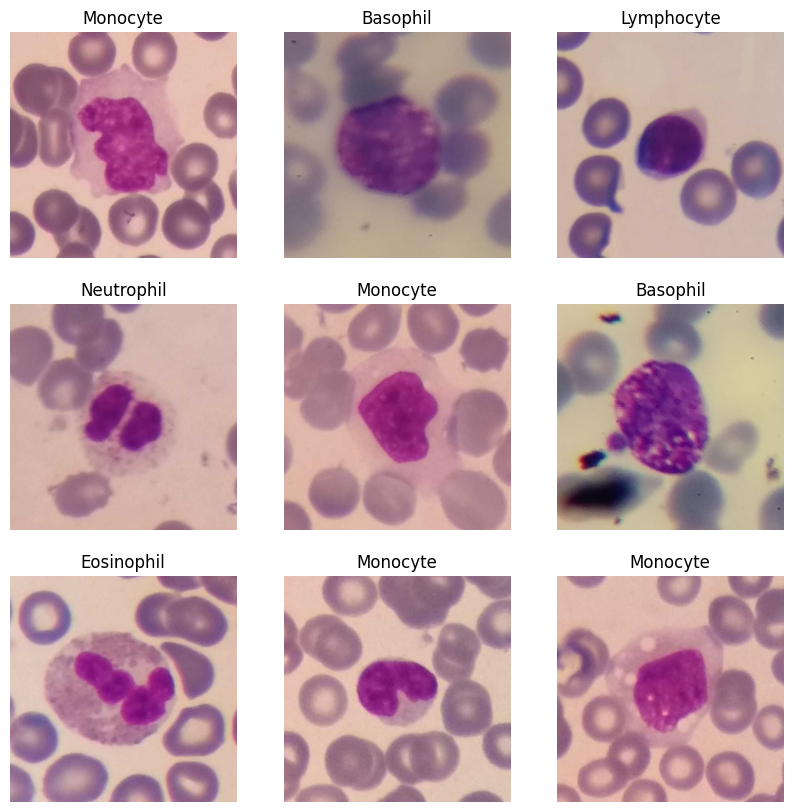

In [7]:
# Display sample images from the dataset

import random
from PIL import Image
plt.figure(figsize=(10,10))

for i in range(9):

    class_name = random.choice(classes)

    class_path = os.path.join(train_path, class_name)

    img_name = random.choice(os.listdir(class_path))

    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

In [8]:
# Check sample image sizes from the dataset
image_sizes = []

for class_name in classes:

    class_path = os.path.join(train_path,class_name)

    images = os.listdir(class_path)[:5]

    for img_name in images:

        img_path = os.path.join(class_path,img_name)

        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)
        except:
            pass

print("Sample image sizes:")
print(image_sizes[:10])

Sample image sizes:
[(575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575), (575, 575)]


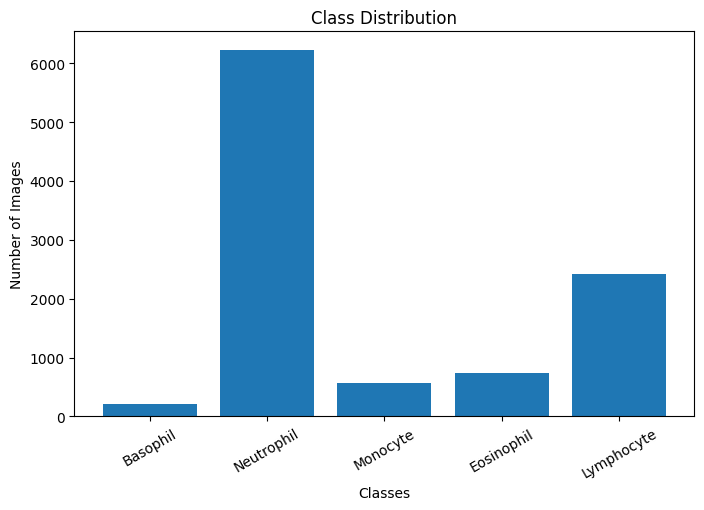

In [9]:
# Plot dataset class distribution
plt.figure(figsize=(8,5))

plt.bar(class_counts.keys(),class_counts.values())

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=30)

plt.show()

In [10]:
# Check if dataset is balanced or imbalanced
max_count = max(class_counts.values())
min_count = min(class_counts.values())

if max_count - min_count > 0:
    print("Dataset has class imbalance")
else:
    print("Dataset is balanced")

Dataset has class imbalance


# **3) Dataset Partitioning (70 / 15 / 15)**

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
# Collect image paths and their corresponding labels

image_paths = []
labels = []

for class_name in os.listdir(train_path):

    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):

        for img in os.listdir(class_path):

            image_paths.append(os.path.join(class_path, img))
            labels.append(class_name)

print("Total images:", len(image_paths))

Total images: 10175


In [13]:
# First split: 70% Train and 30% temporary data

train_imgs, temp_imgs, train_labels, temp_labels = train_test_split(

    image_paths,
    labels,

    test_size = 0.30,

    stratify = labels,

    random_state = 42
)

In [14]:
# Second split: divide the remaining 30% into 15% Validation and 15% Test

val_imgs, test_imgs, val_labels, test_labels = train_test_split(

    temp_imgs,
    temp_labels,

    test_size = 0.50,

    stratify = temp_labels,

    random_state = 42
)

In [15]:
# Print dataset sizes after splitting

print("Training images:", len(train_imgs))
print("Validation images:", len(val_imgs))
print("Testing images:", len(test_imgs))

Training images: 7122
Validation images: 1526
Testing images: 1527


## **4) Image Preprocessing**

In [16]:
def rgb_to_hsi(img):
    img = img.astype(np.float32) / 255.0

    R = img[:, :, 0]
    G = img[:, :, 1]
    B = img[:, :, 2]

    # Intensity
    I = (R + G + B) / 3.0

    # Saturation
    min_rgb = np.minimum(np.minimum(R, G), B)
    S = np.zeros_like(I)
    denom = R + G + B
    mask = denom > 1e-8
    S[mask] = 1 - (3 * min_rgb[mask] / denom[mask])

    # Hue
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B) * (G - B)) + 1e-8
    theta = np.arccos(np.clip(num / den, -1, 1))

    H = np.zeros_like(I)
    H[B <= G] = theta[B <= G]
    H[B > G] = 2 * np.pi - theta[B > G]

    H = H / (2 * np.pi)  # normalize to [0,1]

    return np.stack([H, S, I], axis=-1)


def hsi_to_rgb(hsi):
    H = hsi[:, :, 0] * 2 * np.pi
    S = hsi[:, :, 1]
    I = hsi[:, :, 2]

    R = np.zeros_like(I)
    G = np.zeros_like(I)
    B = np.zeros_like(I)

    # Sector 1: 0 <= H < 2pi/3
    mask1 = (H >= 0) & (H < 2 * np.pi / 3)
    B[mask1] = I[mask1] * (1 - S[mask1])
    R[mask1] = I[mask1] * (
        1 + (S[mask1] * np.cos(H[mask1])) / (np.cos(np.pi / 3 - H[mask1]) + 1e-8)
    )
    G[mask1] = 3 * I[mask1] - (R[mask1] + B[mask1])

    # Sector 2: 2pi/3 <= H < 4pi/3
    mask2 = (H >= 2 * np.pi / 3) & (H < 4 * np.pi / 3)
    H2 = H[mask2] - 2 * np.pi / 3
    R[mask2] = I[mask2] * (1 - S[mask2])
    G[mask2] = I[mask2] * (
        1 + (S[mask2] * np.cos(H2)) / (np.cos(np.pi / 3 - H2) + 1e-8)
    )
    B[mask2] = 3 * I[mask2] - (R[mask2] + G[mask2])

    # Sector 3: 4pi/3 <= H < 2pi
    mask3 = (H >= 4 * np.pi / 3) & (H < 2 * np.pi)
    H3 = H[mask3] - 4 * np.pi / 3
    G[mask3] = I[mask3] * (1 - S[mask3])
    B[mask3] = I[mask3] * (
        1 + (S[mask3] * np.cos(H3)) / (np.cos(np.pi / 3 - H3) + 1e-8)
    )
    R[mask3] = 3 * I[mask3] - (G[mask3] + B[mask3])

    rgb = np.stack([R, G, B], axis=-1)
    rgb = np.clip(rgb, 0, 1)
    rgb = (rgb * 255).astype(np.uint8)

    return rgb


def preprocess_image_hsi(img_path, size=(224, 224)):
    # read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # resize
    img = cv2.resize(img, size)

    # RGB -> HSI
    hsi = rgb_to_hsi(img)

    # split HSI channels
    H = hsi[:, :, 0]
    S = hsi[:, :, 1]
    I = hsi[:, :, 2]

    # Histogram Equalization on Intensity
    I_uint8 = np.clip(I * 255, 0, 255).astype(np.uint8)
    I_eq = cv2.equalizeHist(I_uint8).astype(np.float32) / 255.0

    # replace original intensity channel
    hsi_eq = np.stack([H, S, I_eq], axis=-1)

    # HSI -> RGB
    img_eq = hsi_to_rgb(hsi_eq)

    # normalization
    img_eq = img_eq.astype("float32") / 255.0

    return img_eq

In [17]:
X_train = np.array([preprocess_image_hsi(p) for p in train_imgs])
X_val   = np.array([preprocess_image_hsi(p) for p in val_imgs])
X_test  = np.array([preprocess_image_hsi(p) for p in test_imgs])

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (7122, 224, 224, 3)
X_val shape: (1526, 224, 224, 3)
X_test shape: (1527, 224, 224, 3)


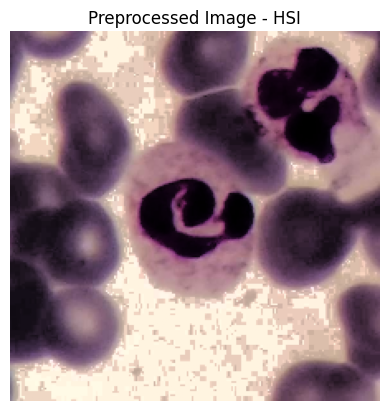

In [18]:
sample = preprocess_image_hsi(train_imgs[0])

plt.imshow(sample)
plt.title("Preprocessed Image - HSI")
plt.axis("off")
plt.show()

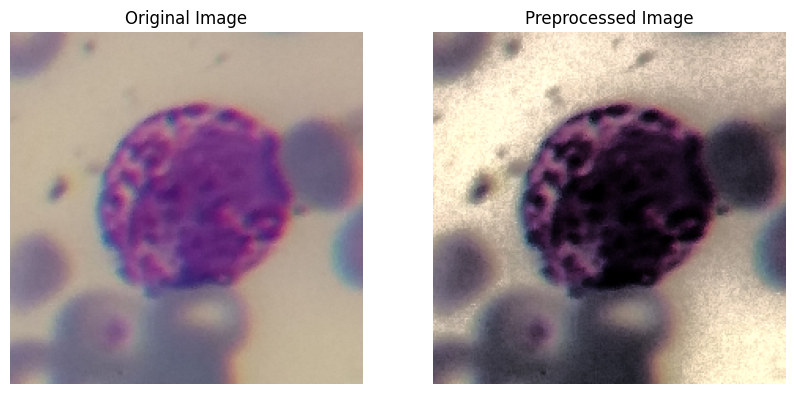

In [19]:
# Test preprocessing on one sample image

sample_class = classes[0]
sample_image_name = os.listdir(os.path.join(train_path, sample_class))[0]
sample_image_path = os.path.join(train_path, sample_class, sample_image_name)

# Original image
original = cv2.imread(sample_image_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
original = cv2.resize(original, (224, 224))

# Processed image
processed = preprocess_image_hsi(sample_image_path)

# Display comparison
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed)
plt.title("Preprocessed Image")
plt.axis("off")

plt.show()

# 5) Augmentation

2026-04-11 03:18:59.868883: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


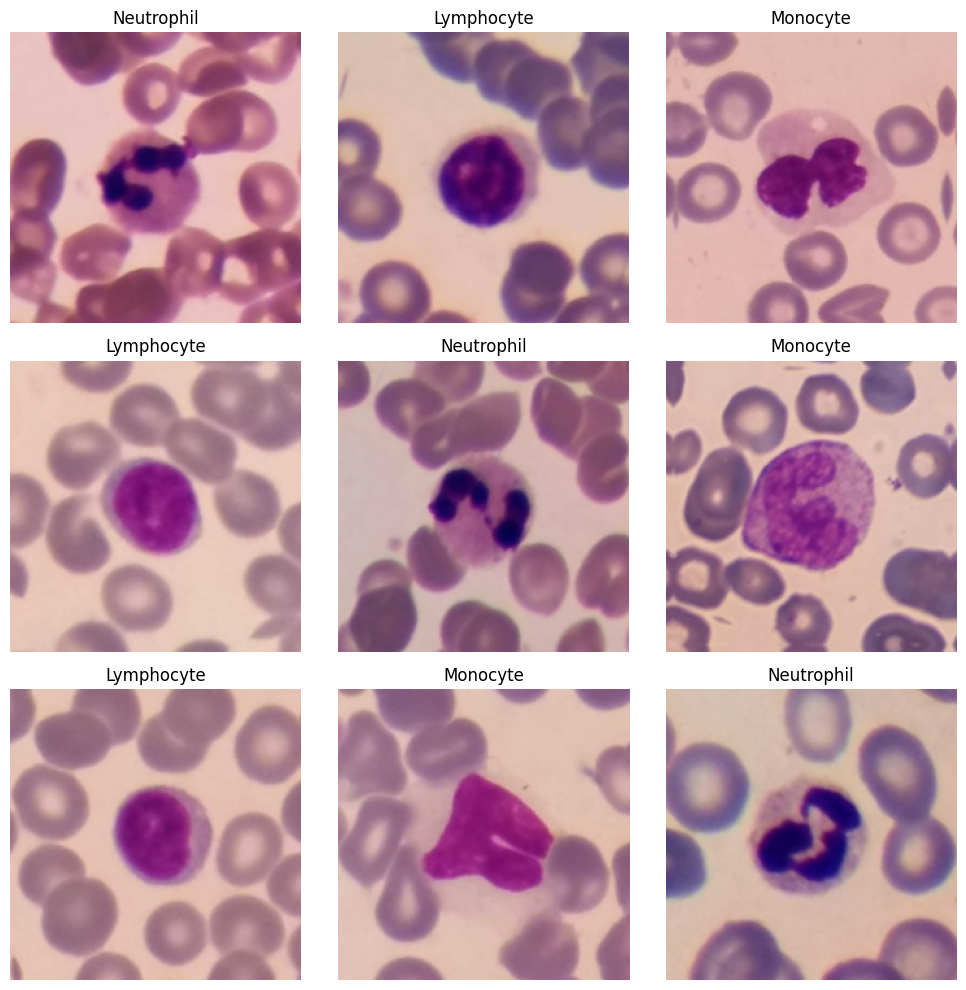

In [20]:
import tensorflow as tf
import matplotlib.pyplot as plt

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")


augmented_train_data = train_data.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)


augmented_train_data = augmented_train_data.prefetch(buffer_size=tf.data.AUTOTUNE)
val_data = val_data.prefetch(buffer_size=tf.data.AUTOTUNE)

class_names = train_data.class_names

plt.figure(figsize=(10, 10))

for images, labels in augmented_train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        img = tf.cast(images[i], tf.uint8)
        plt.imshow(img.numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

# 6) Model Selection & Transfer Learning

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Class names:", class_names)

Number of classes: 5
Class names: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


In [22]:
base_model = tf.keras.applications.EfficientNetV2B0(
    weights='imagenet',
    include_top=False,
    include_preprocessing=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [23]:
eff_model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

eff_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,248,533 (23.84 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [24]:
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
callbacks_eff = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        "best_efficientnetv2.keras",
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

In [26]:
history_eff = eff_model.fit(
    augmented_train_data,
    validation_data=val_data,
    epochs=8,
    callbacks=callbacks_eff
)

Epoch 1/8
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7309 - loss: 0.7384
Epoch 1: val_accuracy improved from None to 0.85711, saving model to best_efficientnetv2.keras

Epoch 1: finished saving model to best_efficientnetv2.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 495s 2s/step - accuracy: 0.7985 - loss: 0.5692 - val_accuracy: 0.8571 - val_loss: 0.3913 - learning_rate: 0.0010
Epoch 2/8
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step - accuracy: 0.8526 - loss: 0.4226
Epoch 2: val_accuracy improved from 0.85711 to 0.88407, saving model to best_efficientnetv2.keras

Epoch 2: finished saving model to best_efficientnetv2.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.8625 - loss: 0.3923 - val_accuracy: 0.8841 - val_loss: 0.3226 - learning_rate: 0.0010
Epoch 3/8
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8740 - loss: 0.3516
Epoch 3: val_accuracy improved from 0.88407 to 0.90136, saving model to best_efficientnetv2.keras

Epoch 3: finished saving model to best_efficien

In [27]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [28]:
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
history_eff_ft = eff_model.fit(
    augmented_train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks_eff
)

Epoch 1/5
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 975ms/step - accuracy: 0.7207 - loss: 0.8818
Epoch 1: val_accuracy did not improve from 0.91588
318/318 ━━━━━━━━━━━━━━━━━━━━ 417s 1s/step - accuracy: 0.7837 - loss: 0.6757 - val_accuracy: 0.8827 - val_loss: 0.3588 - learning_rate: 1.0000e-05
Epoch 2/5
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 999ms/step - accuracy: 0.8681 - loss: 0.3972
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 2: val_accuracy did not improve from 0.91588
318/318 ━━━━━━━━━━━━━━━━━━━━ 404s 1s/step - accuracy: 0.8794 - loss: 0.3662 - val_accuracy: 0.9127 - val_loss: 0.2644 - learning_rate: 1.0000e-05
Epoch 3/5
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 992ms/step - accuracy: 0.8907 - loss: 0.3281
Epoch 3: val_accuracy improved from 0.91588 to 0.91611, saving model to best_efficientnetv2.keras

Epoch 3: finished saving model to best_efficientnetv2.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 402s 1s/step - accuracy: 0.8905 - loss: 0.3211 - val_accuracy: 0.9161 - val_loss

In [30]:
test_data = tf.keras.utils.image_dataset_from_directory(
    test_a_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 4339 files belonging to 5 classes.


In [31]:
test_loss, test_acc = eff_model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

136/136 ━━━━━━━━━━━━━━━━━━━━ 85s 625ms/step - accuracy: 0.8827 - loss: 0.3588
Test Loss: 0.35875314474105835
Test Accuracy: 0.8826918601989746


ConvNeXt


In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [33]:
conv_base = tf.keras.applications.ConvNeXtTiny(
    include_top=False,
    include_preprocessing=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

conv_base.trainable = False

In [34]:
conv_model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    conv_base,

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

conv_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,018,277 (106.88 MB)

 Trainable params: 198,149 (774.02 KB)

 Non-trainable params: 27,820,128 (106.13 MB)

In [35]:
conv_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
callbacks_conv = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        "best_convnext.keras",
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

In [37]:
history_conv = conv_model.fit(
    augmented_train_data,
    validation_data=val_data,
    epochs=8,
    callbacks=callbacks_conv
)

Epoch 1/8


I0000 00:00:1775871317.890652 2853346 service.cc:145] XLA service 0x7f8085369ab0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775871317.891875 2853346 service.cc:153]   StreamExecutor device (0): Host, Default Version
2026-04-11 04:35:17.898545: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775871318.190454 2853346 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.6842 - loss: 0.9076 
Epoch 1: val_accuracy improved from None to 0.76654, saving model to best_convnext.keras

Epoch 1: finished saving model to best_convnext.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 7650s 24s/step - accuracy: 0.7639 - loss: 0.6818 - val_accuracy: 0.7665 - val_loss: 0.6298 - learning_rate: 0.0010
Epoch 2/8
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 18s/step - accuracy: 0.8423 - loss: 0.4454 
Epoch 2: val_accuracy improved from 0.76654 to 0.84513, saving model to best_convnext.keras

Epoch 2: finished saving model to best_convnext.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 7784s 25s/step - accuracy: 0.8514 - loss: 0.4283 - val_accuracy: 0.8451 - val_loss: 0.4521 - learning_rate: 0.0010
Epoch 3/8
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.8725 - loss: 0.3735 
Epoch 3: val_accuracy did not improve from 0.84513
318/318 ━━━━━━━━━━━━━━━━━━━━ 7641s 24s/step - accuracy: 0.8751 - loss: 0.3590 - val_accuracy: 0.8375 - val_loss: 0.4455 - 

In [38]:
conv_base.trainable = True

for layer in conv_base.layers[:-30]:
    layer.trainable = False

In [39]:
conv_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
history_conv_ft = conv_model.fit(
    augmented_train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks_conv
)

Epoch 1/5
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 28s/step - accuracy: 0.9030 - loss: 0.2890 
Epoch 1: val_accuracy did not improve from 0.84513
318/318 ━━━━━━━━━━━━━━━━━━━━ 11021s 35s/step - accuracy: 0.9124 - loss: 0.2587 - val_accuracy: 0.8354 - val_loss: 0.4398 - learning_rate: 1.0000e-05
Epoch 2/5
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 28s/step - accuracy: 0.9266 - loss: 0.2071 
Epoch 2: val_accuracy did not improve from 0.84513
318/318 ━━━━━━━━━━━━━━━━━━━━ 10925s 34s/step - accuracy: 0.9332 - loss: 0.1918 - val_accuracy: 0.8366 - val_loss: 0.4480 - learning_rate: 1.0000e-05
Epoch 3/5
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 28s/step - accuracy: 0.9472 - loss: 0.1584 
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy did not improve from 0.84513
318/318 ━━━━━━━━━━━━━━━━━━━━ 11226s 35s/step - accuracy: 0.9484 - loss: 0.1541 - val_accuracy: 0.8338 - val_loss: 0.4662 - learning_rate: 1.0000e-05
Epoch 4/5
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 29s/step - accuracy: 0.

In [41]:
test_loss_conv, test_acc_conv = conv_model.evaluate(test_data)

print("ConvNeXt Test Loss:", test_loss_conv)
print("ConvNeXt Test Accuracy:", test_acc_conv)

136/136 ━━━━━━━━━━━━━━━━━━━━ 2222s 16s/step - accuracy: 0.8769 - loss: 0.3342
ConvNeXt Test Loss: 0.33415231108665466
ConvNeXt Test Accuracy: 0.8769301772117615


# 7) Hybrid Model (EfficientNetV2B0 + ConvNeXtTiny)

In [42]:
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Hybrid model: two parallel CNN backbones + feature fusion + final classifier
hybrid_eff_base = tf.keras.applications.EfficientNetV2B0(
    weights='imagenet',
    include_top=False,
    include_preprocessing=False,
    input_shape=(224, 224, 3)
)

hybrid_conv_base = tf.keras.applications.ConvNeXtTiny(
    weights='imagenet',
    include_top=False,
    include_preprocessing=False,
    input_shape=(224, 224, 3)
)

hybrid_eff_base.trainable = False
hybrid_conv_base.trainable = False

inputs = layers.Input(shape=(224, 224, 3), name="input_image")
x = data_augmentation(inputs)
x = layers.Rescaling(1./255, name="rescale")(x)

# Branch 1: EfficientNetV2B0
feat_eff = hybrid_eff_base(x, training=False)
feat_eff = layers.GlobalAveragePooling2D(name="eff_gap")(feat_eff)

# Branch 2: ConvNeXtTiny
feat_conv = hybrid_conv_base(x, training=False)
feat_conv = layers.GlobalAveragePooling2D(name="conv_gap")(feat_conv)

# Feature Fusion
fused = layers.Concatenate(name="feature_fusion")([feat_eff, feat_conv])
fused = layers.BatchNormalization(name="fusion_bn")(fused)
fused = layers.Dense(512, activation='relu', name="fusion_dense_1")(fused)
fused = layers.Dropout(0.4, name="fusion_dropout_1")(fused)
fused = layers.Dense(256, activation='relu', name="fusion_dense_2")(fused)
fused = layers.Dropout(0.3, name="fusion_dropout_2")(fused)

outputs = layers.Dense(num_classes, activation='softmax', name="hybrid_output")(fused)

hybrid_model = Model(inputs=inputs, outputs=outputs, name="Hybrid_EfficientNetV2_ConvNeXt")
hybrid_model.summary()


Model: "Hybrid_EfficientNetV2_ConvNeXt"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescale (Rescaling) │ (None, 224, 224,  │          0 │ data_augmentatio… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 7, 7,      │  5,919,312 │ rescale[0][0]     │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny       │ (None, 7, 7, 768) │ 27,820,128 │ rescale[0][0]     │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eff_gap             │ (None, 1280)      │          0 │ efficientnetv2-b… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_gap            │ (None, 768)       │          0 │ convnext_tiny[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 2048)      │          0 │ eff_gap[0][0],    │
│ (Concatenate)       │                   │            │ conv_gap[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn           │ (None, 2048)      │      8,192 │ feature_fusion[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_1      │ (None, 512)       │  1,049,088 │ fusion_bn[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout_1    │ (None, 512)       │          0 │ fusion_dense_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense_2      │ (None, 256)       │    131,328 │ fusion_dropout_1… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout_2    │ (None, 256)       │          0 │ fusion_dense_2[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_output       │ (None, 5)         │      1,285 │ fusion_dropout_2… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 34,929,333 (133.24 MB)

 Trainable params: 1,185,797 (4.52 MB)

 Non-trainable params: 33,743,536 (128.72 MB)

In [43]:

hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_hybrid = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1),
    ModelCheckpoint('best_hybrid_model.keras', monitor='val_accuracy', save_best_only=True)
]

history_hybrid = hybrid_model.fit(
    augmented_train_data,
    validation_data=val_data,
    epochs=8,
    callbacks=callbacks_hybrid
)


Epoch 1/8
318/318 ━━━━━━━━━━━━━━━━━━━━ 7705s 24s/step - accuracy: 0.8308 - loss: 0.5208 - val_accuracy: 0.8606 - val_loss: 0.3929 - learning_rate: 0.0010
Epoch 2/8
318/318 ━━━━━━━━━━━━━━━━━━━━ 7750s 24s/step - accuracy: 0.8959 - loss: 0.3066 - val_accuracy: 0.8751 - val_loss: 0.3761 - learning_rate: 0.0010
Epoch 3/8
170/318 ━━━━━━━━━━━━━━━━━━━━ 45:07 18s/step - accuracy: 0.9032 - loss: 0.2824

KeyboardInterrupt: 

In [ ]:

# Fine-tuning: unfreeze only the last layers from both backbones
hybrid_eff_base.trainable = True
hybrid_conv_base.trainable = True

for layer in hybrid_eff_base.layers[:-30]:
    layer.trainable = False

for layer in hybrid_conv_base.layers[:-30]:
    layer.trainable = False

hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_hybrid_ft = hybrid_model.fit(
    augmented_train_data,
    validation_data=val_data,
    epochs=5,
    callbacks=callbacks_hybrid
)


In [ ]:

hybrid_results = hybrid_model.evaluate(test_data, verbose=1)

print("Hybrid Test Results:")
for metric_name, metric_value in zip(hybrid_model.metrics_names, hybrid_results):
    print(f"{metric_name}: {metric_value:.4f}")


In [ ]:

# Plot training history for the hybrid model
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_hybrid.history['accuracy'], label='train_acc')
plt.plot(history_hybrid.history['val_accuracy'], label='val_acc')
plt.title('Hybrid Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_hybrid.history['loss'], label='train_loss')
plt.plot(history_hybrid.history['val_loss'], label='val_loss')
plt.title('Hybrid Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:

# Optional: save final hybrid model
hybrid_model.save("hybrid_leukemia_model.keras")
print("Hybrid model saved successfully.")
